In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("auto-mpg.csv")

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [10]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [11]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [12]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [13]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [14]:
df = df.dropna()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [16]:
df = df.drop("car name", axis=1)

In [17]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin'],
      dtype='object')

In [18]:
for col in df.columns:
  print(col)


mpg
cylinders
displacement
horsepower
weight
acceleration
model year
origin


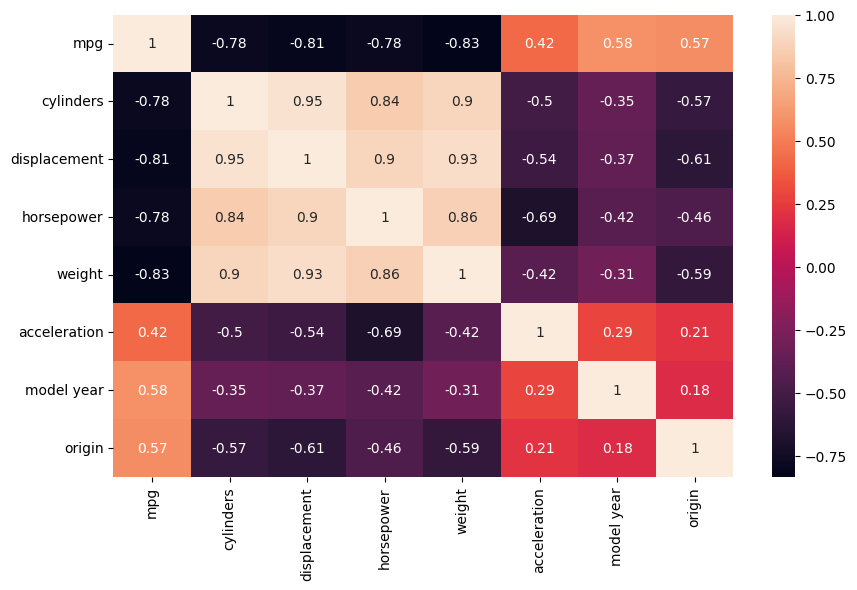

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [20]:
X = df.drop("mpg",axis=1)
y = df['mpg']


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 3.2727457003009515


In [25]:
importance = pd.Series(model.coef_, index=X.columns)

importance.sort_values(ascending=False)

,0
origin,1.613457
model year,0.767743
acceleration,0.037950
displacement,0.015109
weight,-0.006142
horsepower,-0.021302
cylinders,-0.345789


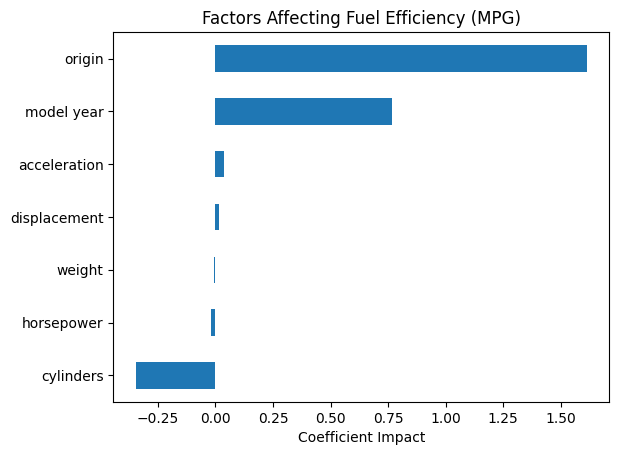

In [26]:
importance.sort_values().plot(kind="barh")
plt.title("Factors Affecting Fuel Efficiency (MPG)")
plt.xlabel("Coefficient Impact")
plt.show()

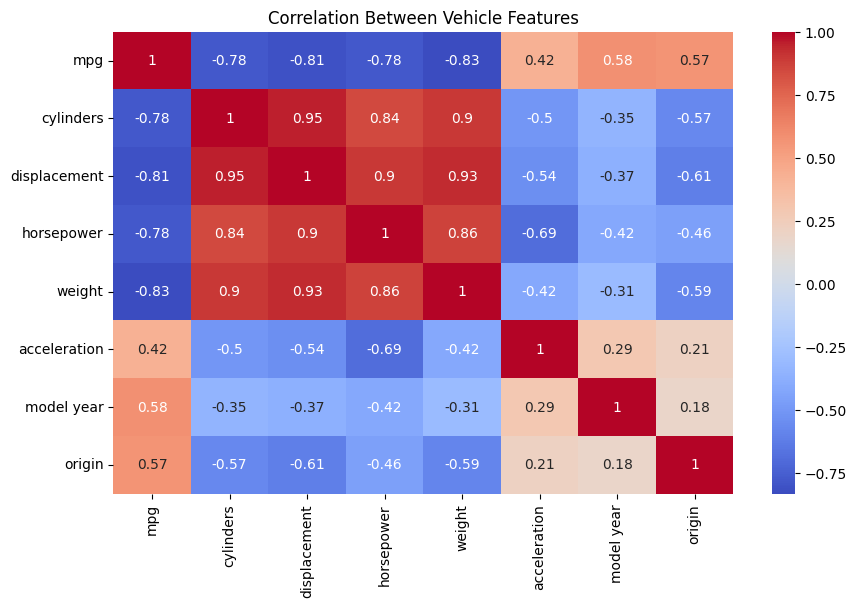

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Vehicle Features")
plt.show()

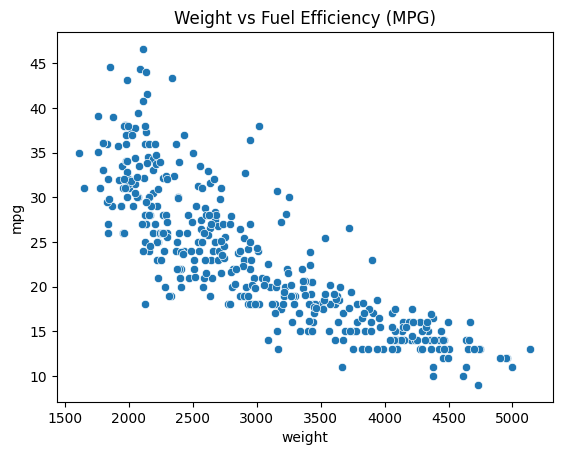

In [28]:
sns.scatterplot(x="weight", y="mpg", data=df)
plt.title("Weight vs Fuel Efficiency (MPG)")
plt.show()

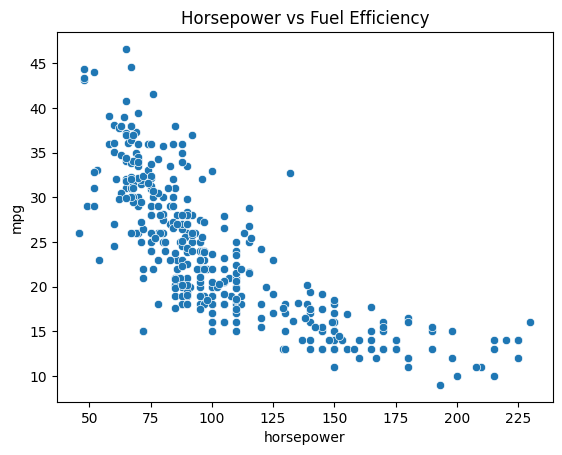

In [29]:
sns.scatterplot(x="horsepower", y="mpg", data=df)
plt.title("Horsepower vs Fuel Efficiency")
plt.show()

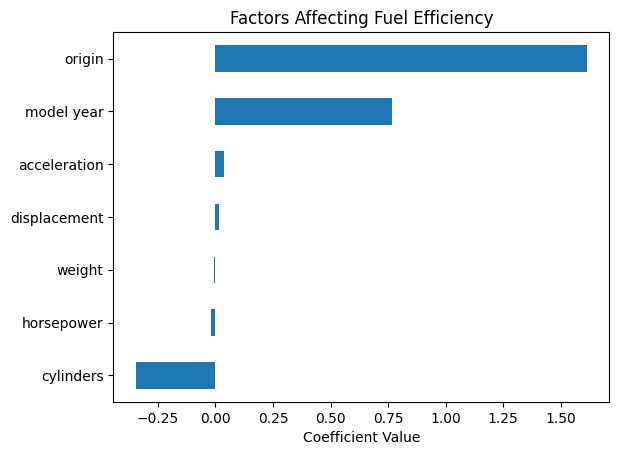

In [30]:
importance = pd.Series(model.coef_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Factors Affecting Fuel Efficiency")
plt.xlabel("Coefficient Value")
plt.show()

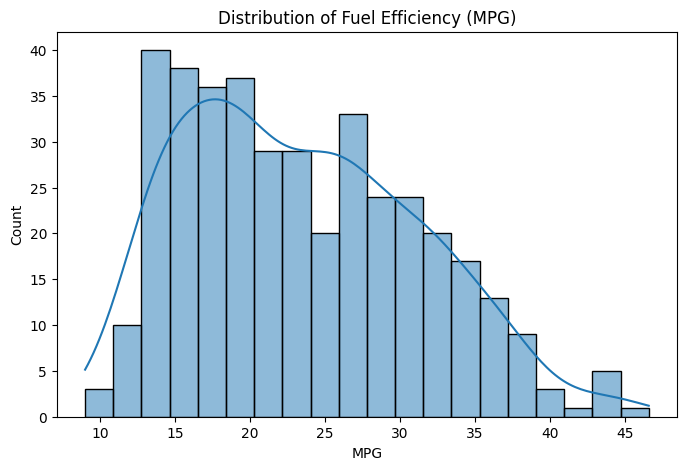

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["mpg"], bins=20, kde=True)

plt.title("Distribution of Fuel Efficiency (MPG)")
plt.xlabel("MPG")
plt.ylabel("Count")

plt.show()

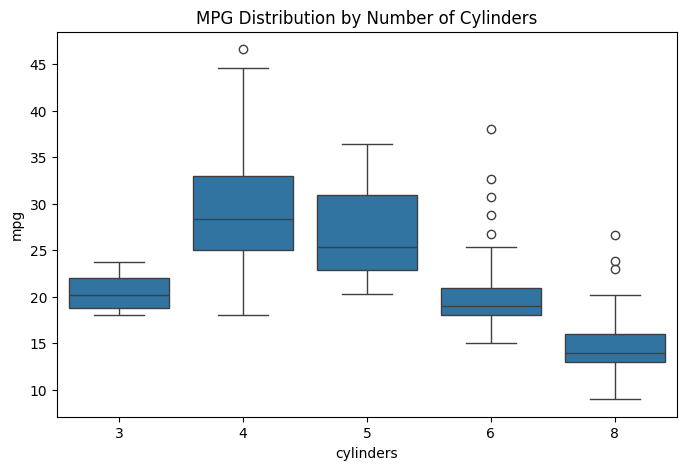

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cylinders", y="mpg", data=df)

plt.title("MPG Distribution by Number of Cylinders")

plt.show()

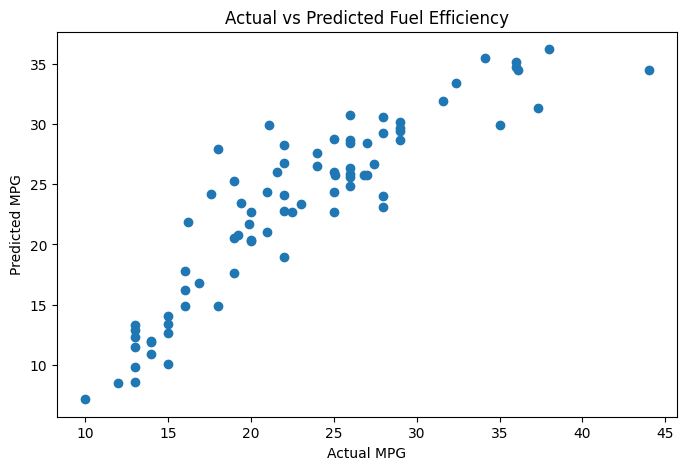

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted Fuel Efficiency")

plt.show()

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [36]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
rf_pred = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 2.3833170321947033


In [39]:
importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance_rf.sort_values(ascending=False)

,0
displacement,0.416357
horsepower,0.168523
weight,0.143825
cylinders,0.137631
model year,0.104867
acceleration,0.024747
origin,0.004049


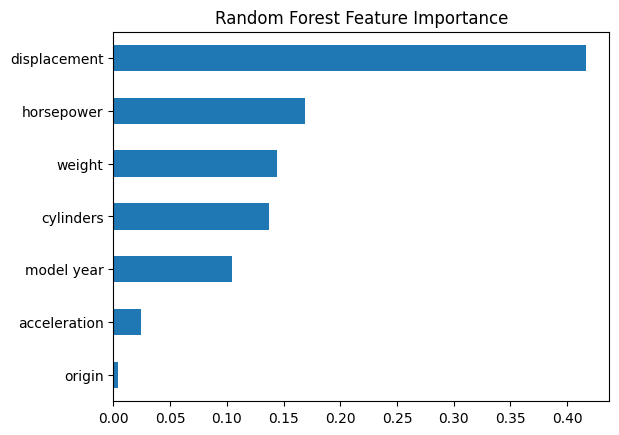

In [40]:
importance_rf.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.show()

In [41]:
from google.colab import files
files.download('auto-mpg.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import joblib
joblib.dump(model, "fuel_efficiency_model.pkl")

['fuel_efficiency_model.pkl']

In [43]:
from google.colab import files
files.download("fuel_efficiency_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>